# __Multiple Scattering Theory (MST)__ - defining and illustating the problem

### This lab provides a guide to defining, simulating, and visualizing systems in MST using the **`QuantumMST`** library tools.


In [1]:
from QuantumMST import scatterer, protein_structure
from QuantumMST import plot_potential
from QuantumMST import generate_system, generate_periodic

In [2]:
import pandas as pd

You can use the built-in reference systems for the spatial layout or a custom geometry defined by providing a list of **`scatterer`** object (with radius **`r`** and depth **`V`**) along with a list of their centers **`positions`**. You need to specify an **`energy`** value to create the **`secular_matrix`**. Systems with two, four and twenty-one scatterers are used as examples.


The class used to store the system attributes is named **`protein_structure`** because this method may eventually be used to simulate proteins. However, this naming should not limit our interpretation or application of the method.

In [3]:
system2 = protein_structure(energy = -3, reference_system = 1)
system21 = protein_structure(reference_system = 5)

In [4]:
rA, VA, xA = 0.8, -5, -1
rB, VB, RAB = 0.6, -6, 2

s1 = scatterer(r=rA, V=VA)
s2 = scatterer(rB, VB)
s3 = scatterer(r=rA-0.1, V=VB-1)

system4 = protein_structure(scatterers = [s1, s3, s2, s1], positions =  [xA, xA+RAB, xA+2*RAB, xA+2*RAB+3])


After defining the geometry of the system, you can generate the potential by specifying the **`resolution`** (default: 100) and a margin dx around the outermost scatterers (default: 2.0).

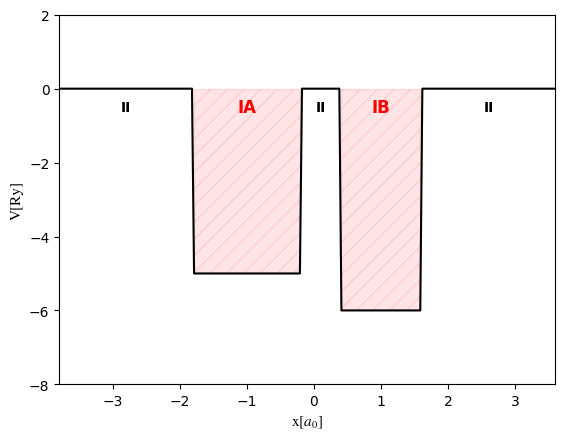

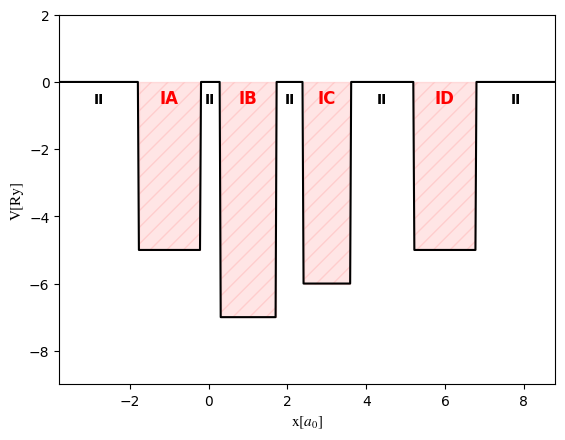

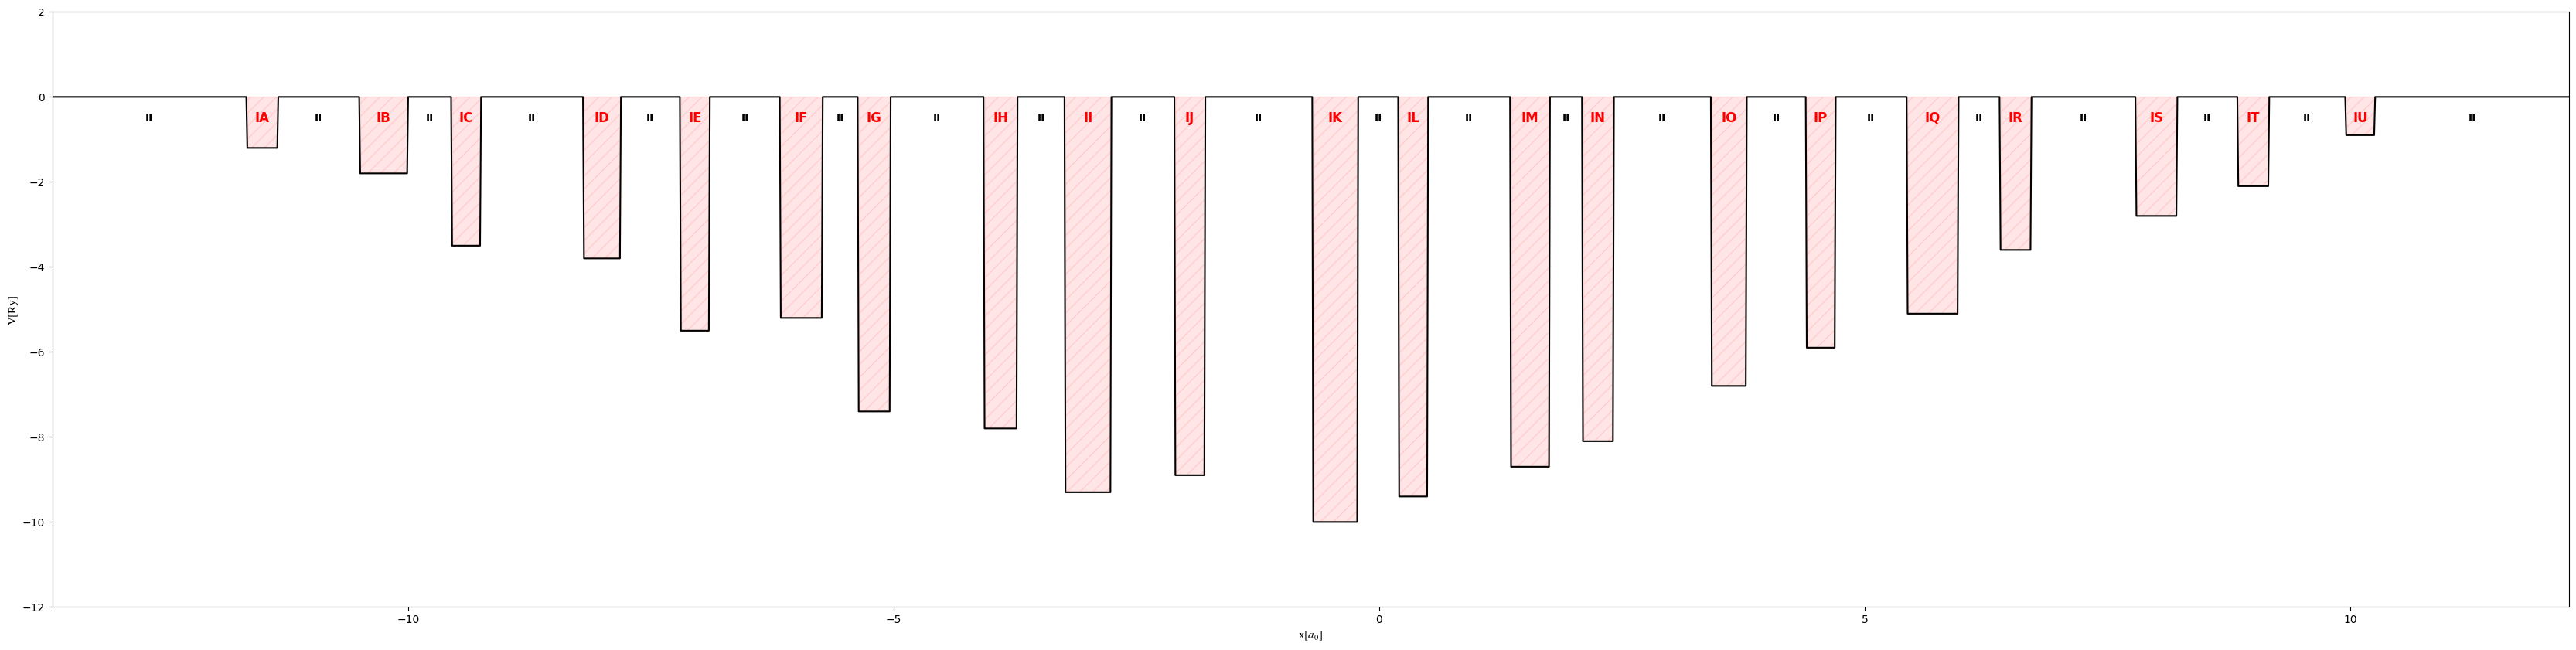

In [5]:
for system in [system2, system4, system21]:
    V, x = system.potential(resolution = 120)
    plot_potential(system)

Once the energy and geometry are provided, the secular matrix is calculated automatically.

In [ ]:
# A system with previously defined energy
display(pd.DataFrame(system2.secular_matrix))

,0,1,2,3
0,-0.033143-0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
1,0.000000+0.000000j,-0.246453+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,-0.062880-0.000000j,0.000000+0.000000j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.650747+0.000000j


In [ ]:
# A system in which the energy has to be provided
system4.energy = -3
display(pd.DataFrame(system4.secular_matrix))

,0,1,2,3,4,5,6,7
0,-0.033143-0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000980-0.000000j,-0.000000-0.000980j,-0.000005-0.000000j,-0.000000-0.000005j
1,0.000000+0.000000j,-0.246453+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000980j,-0.000980-0.000000j,-0.000000+0.000005j,-0.000005-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,-0.122929-0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j,-0.000173-0.000000j,-0.000000-0.000173j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.233999+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j,-0.000000+0.000173j,-0.000173-0.000000j
4,-0.000980-0.000000j,-0.000000+0.000980j,-0.031301-0.000000j,-0.000000+0.031301j,-0.062880-0.000000j,0.000000+0.000000j,-0.005538-0.000000j,-0.000000-0.005538j
5,-0.000000-0.000980j,-0.000980-0.000000j,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.650747+0.000000j,-0.000000+0.005538j,-0.005538-0.000000j
6,-0.000005-0.000000j,-0.000000+0.000005j,-0.000173-0.000000j,-0.000000+0.000173j,-0.005538-0.000000j,-0.000000+0.005538j,-0.033143-0.000000j,0.000000+0.000000j
7,-0.000000-0.000005j,-0.000005-0.000000j,-0.000000-0.000173j,-0.000173-0.000000j,-0.000000-0.005538j,-0.005538-0.000000j,0.000000+0.000000j,-0.246453+0.000000j


Dedicated functions are also available to generate random systems (**`generate_sysytem`**) with specified scatterer counts and parameter bounds, as well as strictly periodic configurations (**`generate_periodic`**).

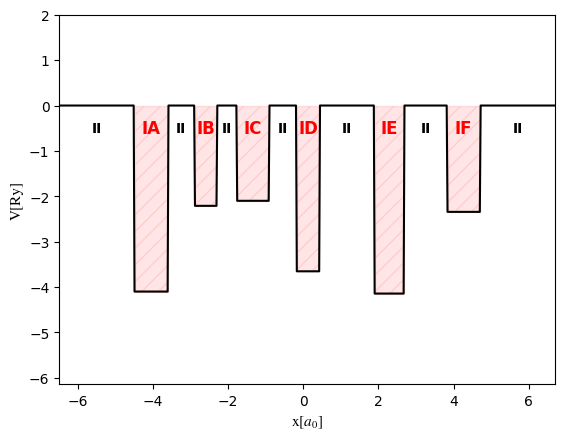

In [8]:
s, positions = generate_system(
    number=6,
    min_dist_pot=0.5,
    rmin=0.2,
    rmax=0.6,       
    Vmin=-5.0,
    Vmax=-2.0,      
    xmin=-5,
    xmax=5
)
system_random = protein_structure(scatterers = s, positions = positions)
system_random.potential()
plot_potential(system_random)

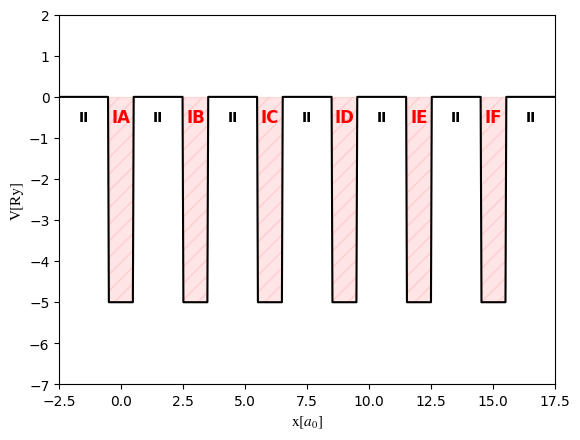

In [9]:
s, positions = generate_periodic(number=6, dis=3.0, r=0.5, V=-5.0)
system_even = protein_structure(scatterers = s, positions = positions)
system_even.potential()
plot_potential(system_even)